In [1]:
!pip install torch torchvision torchaudio

In [2]:
import numpy as np
import torch 
import torch.nn as nn
import matplotlib.pyplot as plt

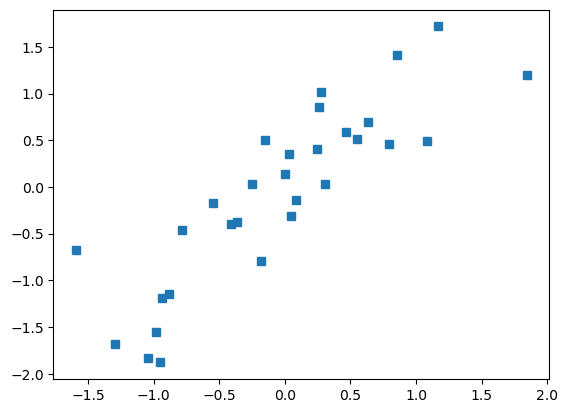

In [3]:
##create a dataset 
N=30
x = torch.randn(N,1)
y = x+torch.randn(N,1)/2

plt.plot(x,y,'s')
plt.show()

In [4]:
##building model
ANNreg = nn.Sequential(
    nn.Linear(1,1), #Input layer
    nn.ReLU(), ##Activation Funtion
    nn.Linear(1,1) ##Output layer
)

ANNreg

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
)

In [5]:
# learning rate
learningrate = 0.05

# loss function
lossfun = nn.MSELoss()

# optimizer(the flavor of gradient descent to implement)
optimizer = torch.optim.SGD(ANNreg.parameters(),lr=learningrate)

In [6]:
# train model
numepochs = 500
loss = torch.zeros(numepochs)

for i in range(numepochs):
    yhat = ANNreg(x) #forward pass
    #loss compute
    loss1 = lossfun(yhat,y)
    loss[i] = loss1
    
    #backprop
    optimizer.zero_grad()
    loss1.backward()
    optimizer.step()

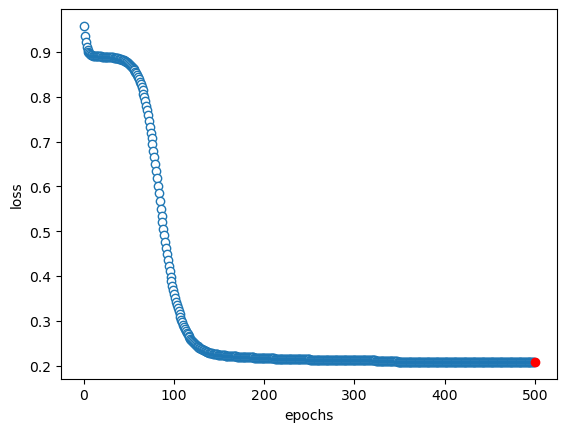

In [7]:
#final forward pass
prediction = ANNreg(x)
testloss = (prediction-y).pow(2).mean()
plt.plot(loss.detach(),'o',markerfacecolor='w',linewidth=.1)
plt.plot(numepochs,testloss.detach(),'ro')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

In [8]:
testloss

tensor(0.2083, grad_fn=<MeanBackward0>)

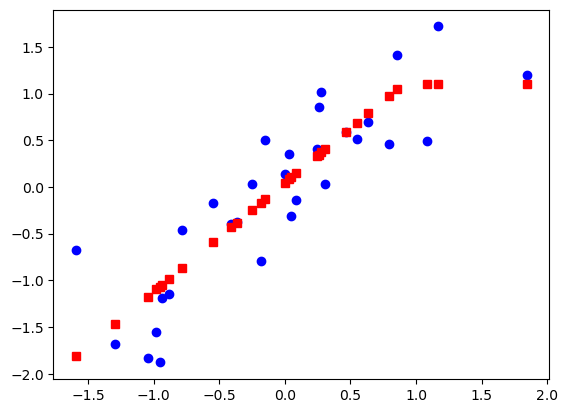

In [10]:
plt.plot(x,y,'bo',label='real data')
plt.plot(x,prediction.detach(),'rs')